In [2]:
!pip install pandas
import pandas as pd
data = {
    'ID': [101, 102, 103, 104, 105],
    'Nombre': ['Vanessa Roldan', 'Jonathan Cardenas', 'Wilder Chacin', 'Jesus Negrette', 'Angel Gomez'],
    'Correo': ['roldanv79@gmail.com', 'fyadocentes@gmail.com', 'wilder11real@gmail.com', 'jesusnegrette05@gmail.com', 'ramonesangel14@gmail.com'],
    'Calificacion': [85, 80, 90, 70, 95],
    'Estado': ['Activo', 'Activo', 'Activo', 'Activo', 'Activo']
}

df_usuarios = pd.DataFrame(data)
print(df_usuarios)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


    ID             Nombre                     Correo  Calificacion  Estado
0  101     Vanessa Roldan        roldanv79@gmail.com            85  Activo
1  102  Jonathan Cardenas      fyadocentes@gmail.com            80  Activo
2  103      Wilder Chacin     wilder11real@gmail.com            90  Activo
3  104     Jesus Negrette  jesusnegrette05@gmail.com            70  Activo
4  105        Angel Gomez   ramonesangel14@gmail.com            95  Activo


Matplotlib is building the font cache; this may take a moment.


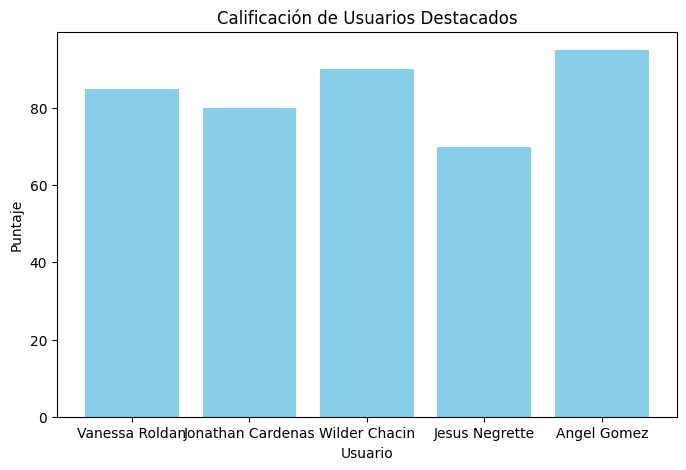

In [3]:
import matplotlib.pyplot as plt

df_calificados = df_usuarios[df_usuarios['Calificacion'] > 60]

plt.figure(figsize=(8, 5))
plt.bar(df_calificados['Nombre'], df_calificados['Calificacion'], color='skyblue')
plt.title('Calificación de Usuarios Destacados')
plt.xlabel('Usuario')
plt.ylabel('Puntaje')


plt.savefig('reporte.png')
plt.show()


In [4]:
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText

# 1. Corregimos los argumentos y añadimos los dos puntos (:)
def crear_mensaje(emisor, receptor, asunto, cuerpo_HTML):
    
    # 2. Instanciamos el objeto con paréntesis ()
    mensaje = MIMEMultipart() 

    # 3. Asignamos los encabezados (ojo con las mayúsculas de las llaves)
    mensaje['From'] = emisor
    mensaje['To'] = receptor
    mensaje['Subject'] = asunto
    
    # 4. Adjuntamos el HTML
    mensaje.attach(MIMEText(cuerpo_HTML, 'html'))

    # 5. El return debe ir DENTRO de la función
    return mensaje.as_string()

# --- Datos de prueba ---
emisor = "fyadocentes@gmail.com"
receptor= "roldanv79@gmail.com"
asunto= "Tarea de Python"

html_ejemplo = """
<!DOCTYPE html>
<html>
    <body>
        <h1 style="color:Blue;">Hola desde Python!</h1>
        <p>Este es un correo con <b>formato HTML</b>.</p>
        <p>Visita <a href="https://www.python.org">Python.org</a></p>
    </body>
</html>
"""

# 6. Llamamos a la función
resultado_final = crear_mensaje(emisor, receptor, asunto, html_ejemplo)

# 7. Imprimimos el resultado (con comillas en el texto)
print("--- Estructura MIME Generada ---")
print(resultado_final)

--- Estructura MIME Generada ---
Content-Type: multipart/mixed; boundary="===============7044104508701255603=="
MIME-Version: 1.0
From: fyadocentes@gmail.com
To: roldanv79@gmail.com
Subject: Tarea de Python

--===============7044104508701255603==
Content-Type: text/html; charset="us-ascii"
MIME-Version: 1.0
Content-Transfer-Encoding: 7bit


<!DOCTYPE html>
<html>
    <body>
        <h1 style="color:Blue;">Hola desde Python!</h1>
        <p>Este es un correo con <b>formato HTML</b>.</p>
        <p>Visita <a href="https://www.python.org">Python.org</a></p>
    </body>
</html>

--===============7044104508701255603==--



In [5]:
import smtplib

def enviar_correo(destinatario, cuerpo_mensaje, servidor_smtp, puerto, usuario, password):
    try:
        # Configuración del servidor
        server = smtplib.SMTP(servidor_smtp, puerto)
        server.starttls()  # Seguridad
        server.login(usuario, password)
        
        # Envío
        server.sendmail(usuario, destinatario, cuerpo_mensaje)
        server.quit()
        return True
    except Exception as e:
        print(f"Error al enviar a {destinatario}: {e}")
        return False

In [6]:
SMTP_SERVER = "smtp.gmail.com"
SMTP_PORT = 587
SENDER_EMAIL = "roldanv79@gmail.com"
SENDER_PASS = "tu_password_de_aplicacion" # 🔐 ¡Usa tu clave de 16 letras aquí!

def notificar_usuarios(df):
    print("🚀 Iniciando sistema de notificaciones...\n" + "-"*40)
    
    # El HTML que definiste en el paso anterior
    html_template = """
    <html>
        <body style="font-family: Arial;">
            <h2 style="color:Blue;">¡Hola de nuevo!</h2>
            <p>Este es tu reporte de calificación generado automáticamente.</p>
            <p>Sigue así en tu camino con <b>Python</b>.</p>
        </body>
    </html>
    """

    for index, fila in df.iterrows():
        # 1. Generar contenido (PASANDO LOS 4 ARGUMENTOS CORRECTOS)
        # emisor, receptor, asunto, cuerpo_HTML
        msg_ready = crear_mensaje(
            SENDER_EMAIL, 
            fila['Correo'], 
            f"Felicidades {fila['Nombre']} - Tarea de Python", 
            html_template
        )
        
        # 2. Intentar envío (Esto estaba perfecto)
        exito = enviar_correo(
            fila['Correo'], 
            msg_ready, 
            SMTP_SERVER, 
            SMTP_PORT, 
            SENDER_EMAIL, 
            SENDER_PASS
        )
        
        # 3. Log
        status = "✅ ENVIADO" if exito else "❌ ERROR"
        print(f"{status} | Usuario: {fila['Nombre']} | Email: {fila['Correo']}")

# Ejecución final usando el DataFrame filtrado
notificar_usuarios(df_calificados)

🚀 Iniciando sistema de notificaciones...
----------------------------------------
Error al enviar a roldanv79@gmail.com: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials 00721157ae682-79cb7721b82sm39707857b3.15 - gsmtp')
❌ ERROR | Usuario: Vanessa Roldan | Email: roldanv79@gmail.com
Error al enviar a fyadocentes@gmail.com: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials 956f58d0204a3-65019b581e9sm2455363d50.4 - gsmtp')
❌ ERROR | Usuario: Jonathan Cardenas | Email: fyadocentes@gmail.com
Error al enviar a wilder11real@gmail.com: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials 956f58d0204a3-65009203e26sm4512540d50.2 - gsmtp')
❌ ERROR | Usuario: Wilder Chacin | Email: wilder11real@gmail.com
Error al enviar a jesusnegrette05@gmail.c